In [5]:
# Data handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [6]:
# Loading the Dataset
iris = load_iris()
X = iris.data 
df = pd.DataFrame(X, columns = iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
# Standardise feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Determine Optimal number of Clusters
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [10]:
for i, val in enumerate(inertia, start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

Number of clusters = 1, Inertia = 600.00
Number of clusters = 2, Inertia = 222.36
Number of clusters = 3, Inertia = 191.02
Number of clusters = 4, Inertia = 114.35
Number of clusters = 5, Inertia = 91.05
Number of clusters = 6, Inertia = 81.55
Number of clusters = 7, Inertia = 80.78
Number of clusters = 8, Inertia = 64.43
Number of clusters = 9, Inertia = 55.71
Number of clusters = 10, Inertia = 51.12


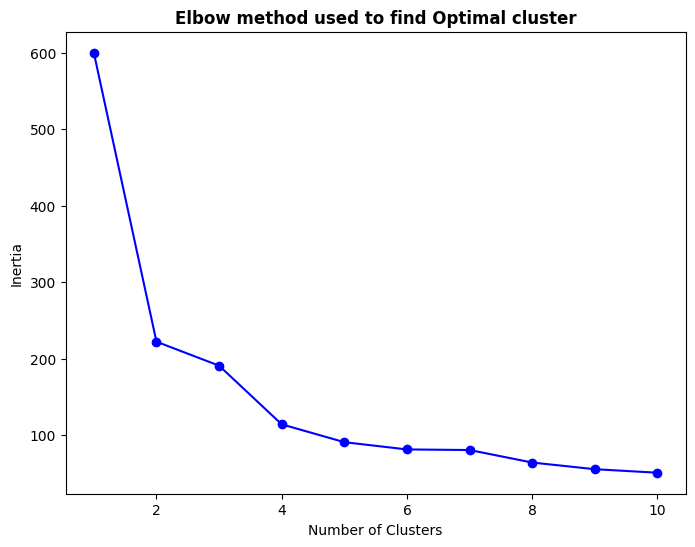

In [11]:
# Visualization
plt.figure(figsize=(8,6))
plt.plot(range(1,11),inertia , marker='o', color='blue')
plt.title('Elbow method used to find Optimal cluster',fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [12]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add the column
df['Clusters'] = clusters
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clusters
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


In [13]:
# Visualize cluster using PCA model
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clusters,PCA1,PCA2
0,5.1,3.5,1.4,0.2,1,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,2,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,2,-2.364229,-0.341908
3,4.6,3.1,1.5,0.2,2,-2.299384,-0.597395
4,5.0,3.6,1.4,0.2,1,-2.389842,0.646835
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,1.870503,0.386966
146,6.3,2.5,5.0,1.9,0,1.564580,-0.896687
147,6.5,3.0,5.2,2.0,0,1.521170,0.269069
148,6.2,3.4,5.4,2.3,0,1.372788,1.011254


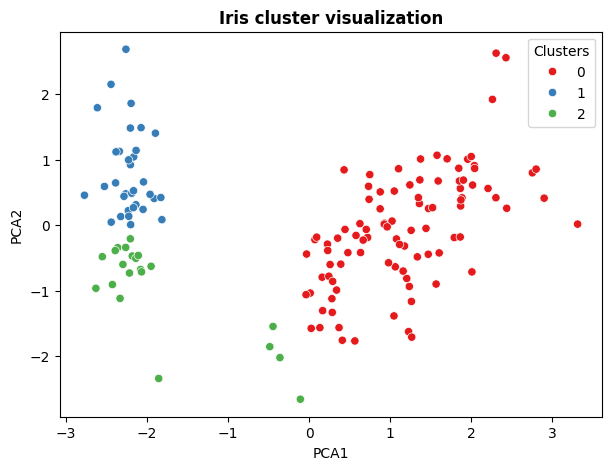

In [14]:
# Visualize
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', palette='Set1', data=df, hue='Clusters')
plt.title('Iris cluster visualization',fontweight='bold')
plt.show()

In [15]:
import joblib
joblib.dump(kmeans,'kmeans.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']